# Amazon E-Commerce Sales Analytics

## 10 — Final Business Insights & Executive Summary

### Objective

This is the final analytical notebook of the Amazon E-Commerce Sales Performance & Customer Analytics project.

The purpose of this notebook is to consolidate the findings from the previous analytical notebooks into an executive-level business summary.

The notebook focuses on:

- Overall business KPIs
- Sales performance
- Product and category performance
- Customer behavior
- Discount and pricing behavior
- Seller performance
- Geographic performance
- Order and payment behavior
- Cross-dimensional relationships
- Business opportunities
- Business risks and limitations
- Data-driven recommendations
- Final project conclusion

### Analytical Scope

This notebook is a synthesis layer. It does not replace the detailed analysis performed in Notebooks 1–9.

The analysis uses the cleaned dataset and recreates the key business metrics required for the final executive summary.


### Important Analytical Limitations

The dataset does not provide:

- Product cost
- Profit or profit margin
- Seller commission
- Seller rating
- Customer rating/review
- Inventory level
- Return amount
- Payment processing cost
- Fraud labels
- Shipping distance
- Latitude/longitude
- Regional market size
- Marketing spend

Therefore, the final recommendations are based on **sales, order, customer, product, discount, seller, geographic, and payment behavior**, not profitability or causal impact.

Observed correlations and patterns should not be interpreted as proof of causation.


## 1. Project Data & Metric Setup

The cleaned dataset is loaded and the common metrics used throughout the project are recreated.

### Core Metrics

- **Gross Product Value** = `Quantity × UnitPrice`
- **Discount Amount** = `Gross Product Value × Discount`
- **Net Product Sales** = `Gross Product Value − Discount Amount`
- **Effective Unit Price** = `UnitPrice × (1 − Discount)`
- **Total Order Value** = `TotalAmount`

The final notebook uses the same metric definitions as the previous notebooks.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the cleaned dataset

file_path = "C:/Users/Hp/OneDrive/Desktop/Projects/Amazon E-Commerce Sales Performance & Customer Analytics/Data/Amazon_Cleaned.csv"

df = pd.read_csv(file_path)

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (100000, 25)


In [3]:
# Confirm fields needed for the final business analysis

required_columns = [
    "OrderID",
    "OrderDate",
    "CustomerID",
    "ProductID",
    "ProductName",
    "Category",
    "Brand",
    "Quantity",
    "UnitPrice",
    "Discount",
    "Tax",
    "ShippingCost",
    "TotalAmount",
    "PaymentMethod",
    "OrderStatus",
    "SellerID",
    "City",
    "State",
    "Country"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All final-analysis columns are available.")


All final-analysis columns are available.


In [4]:
# Create common analytical metrics

df["GrossProductValue"] = (
    df["Quantity"] * df["UnitPrice"]
)

df["DiscountAmount"] = (
    df["GrossProductValue"] * df["Discount"]
)

df["NetProductSales"] = (
    df["GrossProductValue"] - df["DiscountAmount"]
)

df["EffectiveUnitPrice"] = (
    df["UnitPrice"] * (1 - df["Discount"])
)

df["DiscountPercent"] = df["Discount"] * 100

print("Derived metrics created successfully.")


Derived metrics created successfully.


## 2. Executive KPI Dashboard

The following KPIs provide a single high-level view of the dataset.

These metrics are intended to be the primary figures presented to a recruiter, interviewer, or business stakeholder.


In [5]:
executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Sellers",
        "Total Categories",
        "Total Countries",
        "Total Cities",
        "Total Units Sold",
        "Gross Product Value",
        "Total Discount Amount",
        "Net Product Sales",
        "Total Recorded Order Value",
        "Average Order Value",
        "Median Order Value",
        "Average Discount Rate",
        "Weighted Discount Rate"
    ],
    "Value": [
        df["OrderID"].nunique(),
        df["CustomerID"].nunique(),
        df["ProductID"].nunique(),
        df["SellerID"].nunique(),
        df["Category"].nunique(),
        df["Country"].nunique(),
        df["City"].nunique(),
        df["Quantity"].sum(),
        df["GrossProductValue"].sum(),
        df["DiscountAmount"].sum(),
        df["NetProductSales"].sum(),
        df["TotalAmount"].sum(),
        df["TotalAmount"].mean(),
        df["TotalAmount"].median(),
        df["Discount"].mean() * 100,
        (
            df["DiscountAmount"].sum()
            / df["GrossProductValue"].sum()
            * 100
        )
    ]
})

executive_kpis


,KPI,Value
0,Total Orders,1.000000e+05
1,Total Customers,4.323300e+04
2,Total Products,5.000000e+01
3,Total Sellers,1.999000e+03
4,Total Categories,6.000000e+00
5,Total Countries,5.000000e+00
6,Total Cities,2.000000e+01
7,Total Units Sold,3.001400e+05
8,Gross Product Value,9.102121e+07
9,Total Discount Amount,6.783119e+06


### KPI Interpretation

The executive KPI table summarizes the scale of the marketplace.

The most important distinction is between:

- **Gross Product Value** — value before discounts
- **Net Product Sales** — product value after discounts
- **Total Recorded Order Value** — the dataset's total order amount, which includes the recorded tax and shipping components

These measures should not be treated as interchangeable.


## 3. Overall Sales Performance

The final notebook first identifies the strongest sales-level patterns.


In [6]:
sales_summary = pd.DataFrame({
    "Metric": [
        "Gross Product Value",
        "Discount Amount",
        "Net Product Sales",
        "Total Recorded Order Value"
    ],
    "Value": [
        df["GrossProductValue"].sum(),
        df["DiscountAmount"].sum(),
        df["NetProductSales"].sum(),
        df["TotalAmount"].sum()
    ]
})

sales_summary["Share_of_Gross_Product_Value_%"] = (
    sales_summary["Value"]
    / df["GrossProductValue"].sum()
    * 100
)

sales_summary


,Metric,Value,Share_of_Gross_Product_Value_%
0,Gross Product Value,9.102121e+07,100.000000
1,Discount Amount,6.783119e+06,7.452240
2,Net Product Sales,8.423809e+07,92.547760
3,Total Recorded Order Value,9.182565e+07,100.883788


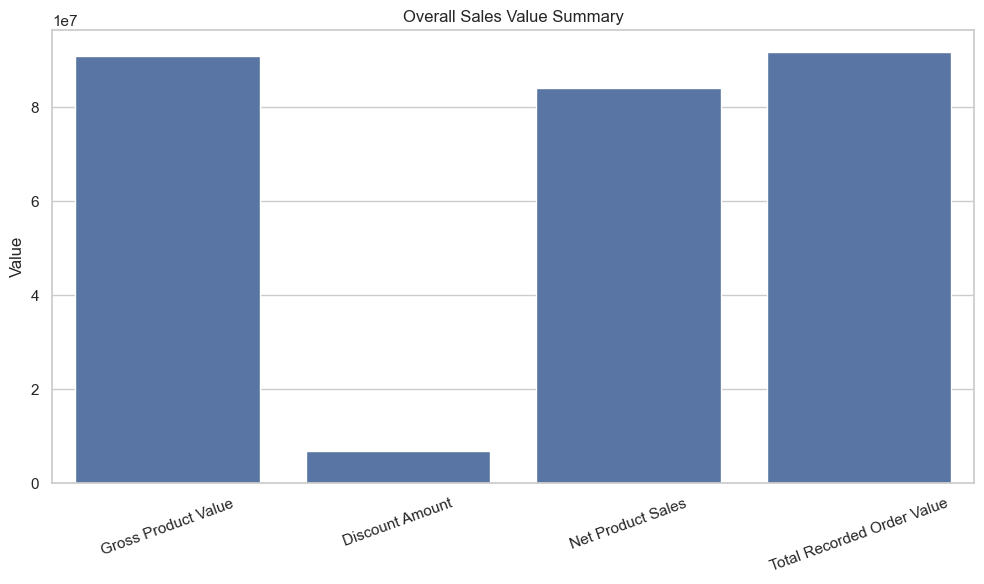

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=sales_summary,
    x="Metric",
    y="Value"
)

plt.title("Overall Sales Value Summary")
plt.xlabel("")
plt.ylabel("Value")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


## 4. Monthly Sales Trend

Monthly sales performance is summarized to identify growth, decline, and high-activity periods within the dataset.


In [8]:
df["OrderMonth"] = df["OrderDate"].dt.to_period("M").astype(str)

monthly_summary = (
    df.groupby("OrderMonth")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Units=("Quantity", "sum"),
          GrossProductValue=("GrossProductValue", "sum"),
          DiscountAmount=("DiscountAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum")
      )
      .reset_index()
)

monthly_summary["Average_Order_Value"] = (
    monthly_summary["TotalOrderValue"]
    / monthly_summary["Orders"]
)

monthly_summary


,OrderMonth,Orders,Customers,Units,GrossProductValue,DiscountAmount,NetProductSales,TotalOrderValue,Average_Order_Value
0,2020-01,1730,1697,5225,1617325.52,116688.1345,1.500637e+06,1637069.40,946.282890
1,2020-02,1490,1473,4343,1324432.59,95613.3225,1.228819e+06,1339388.21,898.918262
2,2020-03,1685,1653,5050,1571380.72,117150.4900,1.454230e+06,1587125.66,941.914338
3,2020-04,1692,1666,5156,1569640.63,112849.5780,1.456791e+06,1588347.29,938.739533
4,2020-05,1672,1639,5061,1523594.32,116265.4180,1.407329e+06,1533834.17,917.364934
5,2020-06,1633,1610,4883,1490683.29,115004.6935,1.375679e+06,1500269.29,918.719712
6,2020-07,1687,1652,5061,1542016.54,117633.7355,1.424383e+06,1552981.94,920.558352
7,2020-08,1783,1753,5439,1628010.52,121617.3405,1.506393e+06,1640874.93,920.288800
8,2020-09,1679,1649,5023,1538920.29,111720.9625,1.427199e+06,1554682.21,925.957242
9,2020-10,1647,1621,4908,1497778.02,107363.1510,1.390415e+06,1515403.62,920.099344


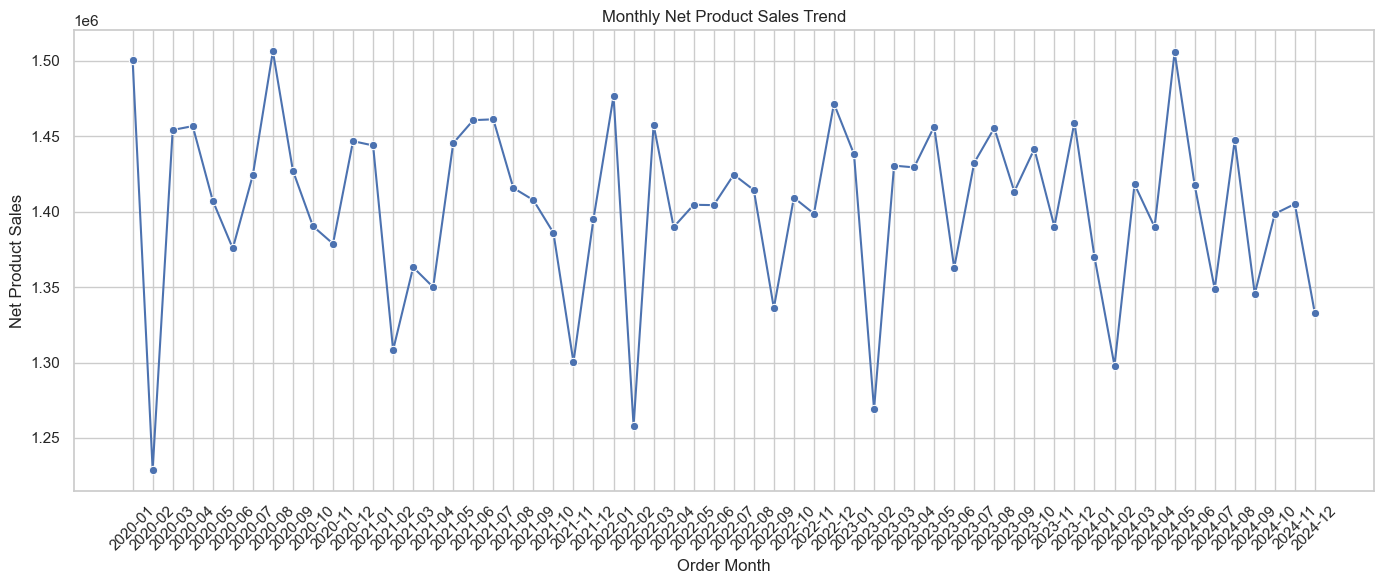

In [9]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_summary,
    x="OrderMonth",
    y="NetProductSales",
    marker="o"
)

plt.title("Monthly Net Product Sales Trend")
plt.xlabel("Order Month")
plt.ylabel("Net Product Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 5. Top Product & Category Insights

This section identifies the highest-performing categories and products.


In [10]:
category_summary = (
    df.groupby("Category")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Products=("ProductID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
)

category_summary["Sales_Share_%"] = (
    category_summary["NetProductSales"]
    / category_summary["NetProductSales"].sum()
    * 100
)

category_summary = category_summary.sort_values(
    "NetProductSales",
    ascending=False
)

category_summary


,Category,Orders,Customers,Products,Units,NetProductSales,TotalOrderValue,Average_Order_Value,Average_Discount,Sales_Share_%
2,Electronics,16853,14235,50,50696,1.428861e+07,15584217.18,924.714720,0.074340,16.962177
4,Sports & Outdoors,16804,14305,50,50543,1.408199e+07,15345571.88,913.209467,0.074000,16.716893
1,Clothing,16439,14031,50,49523,1.399885e+07,15253397.50,927.878673,0.073970,16.618197
0,Books,16752,14294,50,49981,1.399641e+07,15261837.01,911.045667,0.073896,16.615303
5,Toys & Games,16542,14159,50,49773,1.397005e+07,15216684.99,919.881815,0.074066,16.584005
3,Home & Kitchen,16610,14151,50,49624,1.390217e+07,15163939.36,912.940359,0.075084,16.503426


In [11]:
product_summary = (
    df.groupby(["ProductID", "ProductName", "Category"])
      .agg(
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          Average_Unit_Price=("UnitPrice", "mean"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
      .sort_values("NetProductSales", ascending=False)
)

top_products = product_summary.head(20)

top_products


,ProductID,ProductName,Category,Orders,Units,NetProductSales,Average_Unit_Price,Average_Discount
166,P00028,Jeans,Sports & Outdoors,369,1148,343506.7600,311.474526,0.065312
12,P00003,Smartphone Case,Books,358,1120,327517.2130,311.314106,0.073743
47,P00008,4K Monitor,Toys & Games,361,1111,326759.4440,313.555706,0.077147
238,P00040,Microphone,Sports & Outdoors,359,1136,325130.9150,303.724234,0.069916
97,P00017,Electric Kettle,Clothing,362,1106,324504.3030,311.611575,0.071961
115,P00020,Office Chair,Clothing,358,1103,324185.5465,312.580866,0.073324
39,P00007,Mechanical Keyboard,Home & Kitchen,354,1086,322897.3555,317.837373,0.069209
132,P00023,Cookware Set,Books,368,1122,321550.5765,310.872310,0.071467
231,P00039,Graphic Tablet,Home & Kitchen,363,1090,321402.6130,313.058650,0.073140
199,P00034,Desk Organizer,Clothing,369,1101,319594.5845,313.875962,0.079133


## 6. Customer Insights

Customer behavior is summarized using customer reach, order frequency, and customer monetary contribution.


In [12]:
customer_summary = (
    df.groupby("CustomerID")
      .agg(
          Orders=("OrderID", "nunique"),
          Products=("ProductID", "nunique"),
          Categories=("Category", "nunique"),
          Units=("Quantity", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          Average_Order_Value=("TotalAmount", "mean")
      )
      .reset_index()
)

customer_summary["Customer_Segment"] = np.select(
    [
        customer_summary["Orders"] >= 5,
        customer_summary["Orders"].between(3, 4),
        customer_summary["Orders"].between(2, 2)
    ],
    [
        "High Frequency",
        "Medium Frequency",
        "Repeat Customer"
    ],
    default="Single Order"
)

customer_summary.head()


,CustomerID,Orders,Products,Categories,Units,TotalOrderValue,NetProductSales,Average_Order_Value,Customer_Segment
0,CUST000001,1,1,1,1,446.48,408.0240,446.480000,Single Order
1,CUST000002,3,3,2,9,1389.93,1268.6940,463.310000,Medium Frequency
2,CUST000003,1,1,1,5,1116.91,1025.8225,1116.910000,Single Order
3,CUST000004,3,3,2,7,2660.06,2404.7460,886.686667,Medium Frequency
4,CUST000005,1,1,1,4,1089.56,972.0000,1089.560000,Single Order


In [13]:
customer_segment_summary = (
    customer_summary
    .groupby("Customer_Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Orders=("Orders", "sum"),
        Units=("Units", "sum"),
        NetProductSales=("NetProductSales", "sum"),
        Average_Order_Value=("Average_Order_Value", "mean")
    )
    .reset_index()
)

customer_segment_summary["Customer_Share_%"] = (
    customer_segment_summary["Customers"]
    / customer_segment_summary["Customers"].sum()
    * 100
)

customer_segment_summary["Sales_Share_%"] = (
    customer_segment_summary["NetProductSales"]
    / customer_segment_summary["NetProductSales"].sum()
    * 100
)

customer_segment_summary


,Customer_Segment,Customers,Orders,Units,NetProductSales,Average_Order_Value,Customer_Share_%,Sales_Share_%
0,High Frequency,2568,13938,41799,1.166398e+07,912.733726,5.939907,13.846439
1,Medium Frequency,13629,45522,136807,3.847983e+07,921.121928,31.524530,45.679840
2,Repeat Customer,13504,27008,80936,2.266870e+07,914.661185,31.235399,26.910270
3,Single Order,13532,13532,40598,1.142559e+07,920.653999,31.300164,13.563451


### Customer Retention Signal

Repeat-order behavior is treated as an observable engagement signal.

It should not be described as a formal retention or churn metric because the dataset does not contain customer lifecycle, acquisition date, or churn labels.


In [14]:
repeat_customer_rate = (
    (customer_summary["Orders"] > 1).mean() * 100
)

high_frequency_customer_rate = (
    (customer_summary["Orders"] >= 5).mean() * 100
)

print(f"Customers with more than one order: {repeat_customer_rate:.2f}%")
print(f"Customers with five or more orders: {high_frequency_customer_rate:.2f}%")


Customers with more than one order: 68.70%
Customers with five or more orders: 5.94%


## 7. Discount & Pricing Insights

The final summary evaluates discount intensity and identifies whether discounts are concentrated in particular categories.


In [15]:
weighted_discount_rate = (
    df["DiscountAmount"].sum()
    / df["GrossProductValue"].sum()
    * 100
)

average_discount_rate = df["Discount"].mean() * 100

category_discount = (
    df.groupby("Category")
      .agg(
          GrossProductValue=("GrossProductValue", "sum"),
          DiscountAmount=("DiscountAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
)

category_discount["Weighted_Discount_%"] = (
    category_discount["DiscountAmount"]
    / category_discount["GrossProductValue"]
    * 100
)

category_discount = category_discount.sort_values(
    "Weighted_Discount_%",
    ascending=False
)

category_discount


,Category,GrossProductValue,DiscountAmount,NetProductSales,Average_Discount,Weighted_Discount_%
3,Home & Kitchen,15030780.21,1.128609e+06,1.390217e+07,0.075084,7.508652
0,Books,15129134.02,1.132719e+06,1.399641e+07,0.073896,7.487008
1,Clothing,15126422.24,1.127570e+06,1.399885e+07,0.073970,7.454306
4,Sports & Outdoors,15214315.21,1.132323e+06,1.408199e+07,0.074000,7.442487
2,Electronics,15432682.26,1.144068e+06,1.428861e+07,0.074340,7.413281
5,Toys & Games,15087879.05,1.117829e+06,1.397005e+07,0.074066,7.408791


### Discount Interpretation

A high discount rate may coexist with strong sales, but without product cost the analysis cannot determine whether a discount is financially beneficial.

Discount behavior should therefore be interpreted as a **pricing and sales pattern**, not a profitability measure.


## 8. Seller Insights

Seller performance is summarized using sales, orders, customer reach, and product diversity.


In [16]:
seller_summary = (
    df.groupby("SellerID")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Products=("ProductID", "nunique"),
          Categories=("Category", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          Average_Discount=("Discount", "mean")
      )
      .reset_index()
)

seller_summary["Sales_Share_%"] = (
    seller_summary["NetProductSales"]
    / seller_summary["NetProductSales"].sum()
    * 100
)

seller_summary = seller_summary.sort_values(
    "NetProductSales",
    ascending=False
)

seller_summary.head(15)


,SellerID,Orders,Customers,Products,Categories,Units,NetProductSales,TotalOrderValue,Average_Order_Value,Average_Discount,Sales_Share_%
805,SELL00806,67,67,37,6,234,65834.2080,71283.67,1063.935373,0.067910,0.078153
439,SELL00440,61,61,34,6,197,65467.9530,71062.59,1164.960492,0.067213,0.077718
220,SELL00221,65,65,37,6,211,64746.1560,70446.50,1083.792308,0.064615,0.076861
1121,SELL01122,67,67,37,6,217,64326.7825,69469.40,1036.856716,0.085075,0.076363
1224,SELL01225,61,61,37,6,204,64222.3260,70785.92,1160.424918,0.054098,0.076239
708,SELL00709,69,69,39,6,223,64120.9305,70491.92,1021.622029,0.070290,0.076119
811,SELL00812,68,68,36,6,212,63823.1925,68591.86,1008.703824,0.060294,0.075765
993,SELL00994,61,61,35,6,199,63682.7285,69400.06,1137.705902,0.085246,0.075598
535,SELL00536,70,70,39,6,220,63145.1890,69248.00,989.257143,0.079286,0.074960
1921,SELL01922,66,66,38,6,204,62743.6375,68290.28,1034.701212,0.079545,0.074484


In [17]:
top_5_seller_share = (
    seller_summary.head(5)["NetProductSales"].sum()
    / seller_summary["NetProductSales"].sum()
    * 100
)

top_10_seller_share = (
    seller_summary.head(10)["NetProductSales"].sum()
    / seller_summary["NetProductSales"].sum()
    * 100
)

seller_concentration = pd.DataFrame({
    "Seller Group": [
        "Top 5 Sellers",
        "Top 10 Sellers"
    ],
    "Net Product Sales Share (%)": [
        top_5_seller_share,
        top_10_seller_share
    ]
})

seller_concentration


,Seller Group,Net Product Sales Share (%)
0,Top 5 Sellers,0.385333
1,Top 10 Sellers,0.762260


## 9. Geographic Insights

The final notebook summarizes the most important country, state, and city markets.


In [18]:
country_summary = (
    df.groupby("Country")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Cities=("City", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean")
      )
      .reset_index()
      .sort_values("NetProductSales", ascending=False)
)

country_summary["Sales_Share_%"] = (
    country_summary["NetProductSales"]
    / country_summary["NetProductSales"].sum()
    * 100
)

state_summary = (
    df.groupby(["Country", "State"])
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum")
      )
      .reset_index()
      .sort_values("NetProductSales", ascending=False)
)

city_summary = (
    df.groupby(["Country", "State", "City"])
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          Average_Order_Value=("TotalAmount", "mean")
      )
      .reset_index()
      .sort_values("NetProductSales", ascending=False)
)

print("Top countries:")
display(country_summary.head(10))

print("\nTop states:")
display(state_summary.head(10))

print("\nTop cities:")
display(city_summary.head(10))


Top countries:


,Country,Orders,Customers,Cities,Units,NetProductSales,TotalOrderValue,Average_Order_Value,Sales_Share_%
4,United States,70058,37731,20,210409,5.899402e+07,64310048.50,917.954388,70.032468
2,India,15051,12976,20,45082,1.272826e+07,13875839.12,921.921409,15.109856
1,Canada,5818,5486,20,17381,4.885633e+06,5323757.00,915.049330,5.799791
3,United Kingdom,4943,4742,20,14831,4.155828e+06,4526896.86,915.819717,4.933431
0,Australia,4130,3969,20,12437,3.474361e+06,3789106.44,917.459186,4.124454



Top states:


,Country,State,Orders,Customers,Units,NetProductSales
63,United States,TX,17334,14662,52001,1.459125e+07
53,United States,CA,14014,12277,41949,1.171238e+07
37,India,TX,3797,3648,11322,3.214668e+06
59,United States,NC,3606,3467,10867,3.033620e+06
56,United States,FL,3594,3479,10870,3.015114e+06
62,United States,PA,3543,3409,10737,3.014939e+06
57,United States,IL,3507,3402,10521,2.996201e+06
58,United States,IN,3469,3364,10445,2.978152e+06
54,United States,CO,3462,3334,10511,2.972087e+06
61,United States,OH,3521,3392,10597,2.967673e+06



Top cities:


,Country,State,City,Orders,Customers,Units,NetProductSales,Average_Order_Value
90,United States,NC,Charlotte,3606,3467,10867,3.033620e+06,918.435311
95,United States,TX,Dallas,3549,3428,10760,3.028909e+06,930.502998
81,United States,CA,Los Angeles,3571,3445,10654,3.019624e+06,922.321302
87,United States,FL,Jacksonville,3594,3479,10870,3.015114e+06,913.103328
93,United States,PA,Philadelphia,3543,3409,10737,3.014939e+06,927.874663
88,United States,IL,Chicago,3507,3402,10521,2.996201e+06,932.026915
84,United States,CA,San Jose,3619,3492,10815,2.980571e+06,899.963741
89,United States,IN,Indianapolis,3469,3364,10445,2.978152e+06,935.884563
85,United States,CO,Denver,3462,3334,10511,2.972087e+06,935.916534
94,United States,TX,Austin,3481,3369,10350,2.968478e+06,929.521528


## 10. Order & Payment Insights

The final summary combines order status and payment method performance.


In [19]:
order_status_summary = (
    df.groupby("OrderStatus")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Units=("Quantity", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean")
      )
      .reset_index()
)

order_status_summary["Order_Share_%"] = (
    order_status_summary["Orders"]
    / order_status_summary["Orders"].sum()
    * 100
)

payment_summary = (
    df.groupby("PaymentMethod")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean")
      )
      .reset_index()
)

payment_summary["Order_Share_%"] = (
    payment_summary["Orders"]
    / payment_summary["Orders"].sum()
    * 100
)

payment_summary["Sales_Share_%"] = (
    payment_summary["NetProductSales"]
    / payment_summary["NetProductSales"].sum()
    * 100
)

print("Order status performance:")
display(order_status_summary.sort_values("Orders", ascending=False))

print("\nPayment method performance:")
display(payment_summary.sort_values("Orders", ascending=False))


Order status performance:


,OrderStatus,Orders,Customers,Units,NetProductSales,TotalOrderValue,Average_Order_Value,Order_Share_%
1,Delivered,74628,38772,223759,6.273130e+07,68372677.10,916.179947,74.628
4,Shipped,15192,13065,45660,1.291347e+07,14083628.99,927.042456,15.192
2,Pending,4103,3926,12338,3.431175e+06,3737556.98,910.932727,4.103
3,Returned,3049,2958,9141,2.549609e+06,2780662.46,911.991623,3.049
0,Cancelled,3028,2931,9242,2.612540e+06,2851122.39,941.585994,3.028



Payment method performance:


,PaymentMethod,Orders,Customers,NetProductSales,TotalOrderValue,Average_Order_Value,Order_Share_%,Sales_Share_%
2,Credit Card,35038,25173,2.946314e+07,32122158.69,916.780601,35.038,34.976032
3,Debit Card,20024,16545,1.701741e+07,18538678.53,925.822939,20.024,20.201558
5,UPI,15066,13065,1.275142e+07,13896028.55,922.343592,15.066,15.137355
0,Amazon Pay,15017,13022,1.256792e+07,13697498.42,912.132811,15.017,14.919525
4,Net Banking,9927,8989,8.295722e+06,9055674.57,912.226712,9.927,9.847946
1,Cash on Delivery,4928,4689,4.142480e+06,4515609.16,916.316794,4.928,4.917585


## 11. Cross-Dimensional Business Analysis

This section connects multiple dimensions to identify broader patterns rather than analyzing each dimension independently.


In [20]:
# Category × Customer × Sales

category_customer = (
    df.groupby("Category")
      .agg(
          Customers=("CustomerID", "nunique"),
          Orders=("OrderID", "nunique"),
          NetProductSales=("NetProductSales", "sum")
      )
      .reset_index()
)

category_customer["Sales_per_Customer"] = (
    category_customer["NetProductSales"]
    / category_customer["Customers"]
)

category_customer = category_customer.sort_values(
    "Sales_per_Customer",
    ascending=False
)

category_customer


,Category,Customers,Orders,NetProductSales,Sales_per_Customer
2,Electronics,14235,16853,1.428861e+07,1003.766364
1,Clothing,14031,16439,1.399885e+07,997.708815
5,Toys & Games,14159,16542,1.397005e+07,986.655107
4,Sports & Outdoors,14305,16804,1.408199e+07,984.410467
3,Home & Kitchen,14151,16610,1.390217e+07,982.416175
0,Books,14294,16752,1.399641e+07,979.181094


In [21]:
# Country × Category

country_category = (
    df.groupby(["Country", "Category"])
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          NetProductSales=("NetProductSales", "sum")
      )
      .reset_index()
)

country_category["Country_Sales_Share_%"] = (
    country_category["NetProductSales"]
    / country_category.groupby("Country")["NetProductSales"].transform("sum")
    * 100
)

country_category.head(20)


,Country,Category,Orders,Customers,NetProductSales,Country_Sales_Share_%
0,Australia,Books,718,712,6.117273e+05,17.606901
1,Australia,Clothing,706,701,6.014287e+05,17.310483
2,Australia,Electronics,714,707,6.012982e+05,17.306726
3,Australia,Home & Kitchen,619,617,5.069028e+05,14.589813
4,Australia,Sports & Outdoors,697,689,5.868765e+05,16.891636
5,Australia,Toys & Games,676,671,5.661277e+05,16.294440
6,Canada,Books,981,971,7.966429e+05,16.305828
7,Canada,Clothing,901,897,7.662232e+05,15.683191
8,Canada,Electronics,966,957,8.450775e+05,17.297195
9,Canada,Home & Kitchen,1002,992,8.367345e+05,17.126430


In [22]:
# Seller × Geographic market

seller_country = (
    df.groupby(["Country", "SellerID"])
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          NetProductSales=("NetProductSales", "sum")
      )
      .reset_index()
)

seller_country["Country_Sales_Share_%"] = (
    seller_country["NetProductSales"]
    / seller_country.groupby("Country")["NetProductSales"].transform("sum")
    * 100
)

seller_country.head(20)


,Country,SellerID,Orders,Customers,NetProductSales,Country_Sales_Share_%
0,Australia,SELL00001,2,2,2845.4100,0.081897
1,Australia,SELL00002,2,2,3129.0480,0.090061
2,Australia,SELL00003,2,2,1937.3540,0.055761
3,Australia,SELL00004,1,1,121.4700,0.003496
4,Australia,SELL00005,6,6,7039.4620,0.202612
5,Australia,SELL00006,3,3,4003.1050,0.115218
6,Australia,SELL00007,2,2,147.4820,0.004245
7,Australia,SELL00008,3,3,3447.2340,0.099219
8,Australia,SELL00009,1,1,1035.4680,0.029803
9,Australia,SELL00010,3,3,712.0125,0.020493


## 12. Business Opportunity Identification

The following rules identify areas that may deserve further business attention.

These are **analytical flags**, not claims that a business problem definitely exists.


In [23]:
# Category opportunity flags

category_opportunities = category_summary.copy()

sales_median = category_opportunities["NetProductSales"].median()
aov_median = category_opportunities["Average_Order_Value"].median()

category_opportunities["Opportunity_Flag"] = np.select(
    [
        (
            (category_opportunities["NetProductSales"] >= sales_median)
            & (category_opportunities["Average_Order_Value"] >= aov_median)
        ),
        (
            (category_opportunities["NetProductSales"] >= sales_median)
            & (category_opportunities["Average_Order_Value"] < aov_median)
        ),
        (
            (category_opportunities["NetProductSales"] < sales_median)
            & (category_opportunities["Average_Order_Value"] >= aov_median)
        )
    ],
    [
        "High Sales + High AOV",
        "High Sales + Lower AOV",
        "Lower Sales + High AOV"
    ],
    default="Lower Sales + Lower AOV"
)

category_opportunities[
    [
        "Category",
        "NetProductSales",
        "Average_Order_Value",
        "Sales_Share_%",
        "Opportunity_Flag"
    ]
]


,Category,NetProductSales,Average_Order_Value,Sales_Share_%,Opportunity_Flag
2,Electronics,1.428861e+07,924.714720,16.962177,High Sales + High AOV
4,Sports & Outdoors,1.408199e+07,913.209467,16.716893,High Sales + Lower AOV
1,Clothing,1.399885e+07,927.878673,16.618197,High Sales + High AOV
0,Books,1.399641e+07,911.045667,16.615303,Lower Sales + Lower AOV
5,Toys & Games,1.397005e+07,919.881815,16.584005,Lower Sales + High AOV
3,Home & Kitchen,1.390217e+07,912.940359,16.503426,Lower Sales + Lower AOV


## 13. Business Risk Indicators

The project identifies observable concentration and dependency indicators.

These are not financial risk measures; they are indicators that may warrant additional investigation.


In [24]:
risk_indicators = pd.DataFrame({
    "Indicator": [
        "Top 5 seller sales concentration",
        "Top 10 seller sales concentration",
        "Top 5 country sales concentration",
        "Top 20 city sales concentration",
        "Weighted discount rate",
        "Number of payment methods",
        "Number of order statuses"
    ],
    "Value": [
        top_5_seller_share,
        top_10_seller_share,
        (
            country_summary.head(5)["NetProductSales"].sum()
            / country_summary["NetProductSales"].sum()
            * 100
        ),
        (
            city_summary.head(20)["NetProductSales"].sum()
            / city_summary["NetProductSales"].sum()
            * 100
        ),
        weighted_discount_rate,
        df["PaymentMethod"].nunique(),
        df["OrderStatus"].nunique()
    ]
})

risk_indicators


,Indicator,Value
0,Top 5 seller sales concentration,0.385333
1,Top 10 seller sales concentration,0.762260
2,Top 5 country sales concentration,100.000000
3,Top 20 city sales concentration,70.032468
4,Weighted discount rate,7.452240
5,Number of payment methods,6.000000
6,Number of order statuses,5.000000


### Risk Interpretation

High seller or geographic concentration does not automatically mean the business is at risk.

It indicates that a relatively large share of observed sales is associated with a smaller group of sellers or markets. Management would need additional information such as supplier contracts, inventory, profitability, and market alternatives before determining actual business risk.


## 14. Final Business Questions & Answers

The following section generates concise answers to the most important questions from the complete project.


In [25]:
top_category = category_summary.iloc[0]
top_product = product_summary.iloc[0]
top_seller = seller_summary.iloc[0]
top_country = country_summary.iloc[0]
top_city = city_summary.iloc[0]
top_payment = payment_summary.sort_values("Orders", ascending=False).iloc[0]
top_status = order_status_summary.sort_values("Orders", ascending=False).iloc[0]

print("1. Highest-performing category:")
print(
    f"   {top_category['Category']} — "
    f"${top_category['NetProductSales']:,.2f} net product sales"
)

print("\n2. Highest-performing product:")
print(
    f"   {top_product['ProductName']} — "
    f"${top_product['NetProductSales']:,.2f} net product sales"
)

print("\n3. Highest-performing seller:")
print(
    f"   {top_seller['SellerID']} — "
    f"${top_seller['NetProductSales']:,.2f} net product sales"
)

print("\n4. Highest-performing country:")
print(
    f"   {top_country['Country']} — "
    f"${top_country['NetProductSales']:,.2f} net product sales"
)

print("\n5. Highest-performing city:")
print(
    f"   {top_city['City']} ({top_city['State']}, {top_city['Country']}) — "
    f"${top_city['NetProductSales']:,.2f}"
)

print("\n6. Most-used payment method:")
print(
    f"   {top_payment['PaymentMethod']} — "
    f"{int(top_payment['Orders']):,} orders"
)

print("\n7. Most common order status:")
print(
    f"   {top_status['OrderStatus']} — "
    f"{int(top_status['Orders']):,} orders"
)

print("\n8. Weighted discount rate:")
print(
    f"   {weighted_discount_rate:.2f}%"
)

print("\n9. Repeat-customer rate:")
print(
    f"   {repeat_customer_rate:.2f}%"
)


1. Highest-performing category:
   Electronics — $14,288,614.19 net product sales

2. Highest-performing product:
   Jeans — $343,506.76 net product sales

3. Highest-performing seller:
   SELL00806 — $65,834.21 net product sales

4. Highest-performing country:
   United States — $58,994,016.27 net product sales

5. Highest-performing city:
   Charlotte (NC, United States) — $3,033,620.31

6. Most-used payment method:
   Credit Card — 35,038 orders

7. Most common order status:
   Delivered — 74,628 orders

8. Weighted discount rate:
   7.45%

9. Repeat-customer rate:
   68.70%


## 15. Recommended Business Actions

### Recommendation 1 — Focus on High-Value Categories

Prioritize categories that combine strong net product sales with strong average order value.

**Action:** Maintain product availability and evaluate opportunities for cross-selling and premium product placement.

### Recommendation 2 — Strengthen High-Performing Markets

Countries and cities contributing substantial sales should receive attention in inventory planning, seller availability, and customer experience.

**Action:** Compare market concentration with operational capacity before increasing investment.

### Recommendation 3 — Monitor Seller Concentration

If a large percentage of sales depends on a small group of sellers, the marketplace may benefit from strengthening additional sellers.

**Action:** Identify capable secondary sellers and encourage broader product/category participation.

### Recommendation 4 — Evaluate Discount Strategy

High discounts should be reviewed alongside sales volume and customer response.

**Action:** Before increasing discounts, compare the observed sales benefit with product cost and margin data when available.

### Recommendation 5 — Optimize Payment Experience

Payment methods with high adoption and high-value transaction contribution should receive strong operational support.

**Action:** Monitor payment failures, refunds, and processing costs in future datasets.

### Recommendation 6 — Develop Customer Retention Programs

Customers with repeated orders represent an observable engagement segment.

**Action:** Use customer-level purchase frequency and category behavior to design targeted loyalty or cross-selling strategies.

### Recommendation 7 — Build a Profitability Layer

The current project is sales-focused.

**Action:** Add product cost, seller commission, returns, refunds, and marketing costs in a future version to calculate profit and ROI.

### Recommendation 8 — Improve Data Collection

Future analysis would benefit from:

- Seller ratings
- Product ratings
- Returns
- Refunds
- Cost of goods sold
- Profit
- Inventory
- Delivery time
- Payment failures
- Fraud/chargeback indicators
- Marketing spend
- Customer acquisition date


## 16. Executive Summary

The completed analysis provides a multi-dimensional view of e-commerce performance across:

- Sales
- Products
- Categories
- Customers
- Discounts
- Sellers
- Geography
- Orders
- Payments

The strongest value of the project is not a single metric, but the ability to connect these dimensions.

For example:

**Sales → Category → Product → Customer → Seller → Geography → Payment**

This structure allows a business stakeholder to move from identifying *what happened* to understanding *where it happened* and *which business dimensions are associated with the result*.

However, profitability, causal effects, customer churn, fraud, and true operational efficiency cannot be established from the current dataset because the necessary fields are unavailable.


## 17. Final Project KPI Table

This table is designed as a compact reference for the final dashboard, README, portfolio presentation, and interviews.


In [26]:
final_kpi_table = pd.DataFrame({
    "KPI": [
        "Orders",
        "Customers",
        "Products",
        "Sellers",
        "Categories",
        "Countries",
        "Cities",
        "Units Sold",
        "Net Product Sales",
        "Average Order Value",
        "Weighted Discount Rate",
        "Repeat Customer Rate"
    ],
    "Value": [
        df["OrderID"].nunique(),
        df["CustomerID"].nunique(),
        df["ProductID"].nunique(),
        df["SellerID"].nunique(),
        df["Category"].nunique(),
        df["Country"].nunique(),
        df["City"].nunique(),
        df["Quantity"].sum(),
        df["NetProductSales"].sum(),
        df["TotalAmount"].mean(),
        weighted_discount_rate,
        repeat_customer_rate
    ]
})

final_kpi_table


,KPI,Value
0,Orders,1.000000e+05
1,Customers,4.323300e+04
2,Products,5.000000e+01
3,Sellers,1.999000e+03
4,Categories,6.000000e+00
5,Countries,5.000000e+00
6,Cities,2.000000e+01
7,Units Sold,3.001400e+05
8,Net Product Sales,8.423809e+07
9,Average Order Value,9.182565e+02


## 18. Final Portfolio-Ready Findings

Use the following categories of findings when presenting this project:

### Sales
Identify the strongest sales categories, products, sellers, and geographic markets.

### Customer Analytics
Highlight customer reach, repeat ordering, and customer-value patterns.

### Pricing
Explain discount distribution and effective selling price without claiming profitability.

### Seller Analytics
Discuss seller concentration, sales contribution, and product/category diversity.

### Geography
Highlight leading countries, states, and cities and explain sales concentration.

### Orders & Payments
Discuss order status, payment adoption, order value, and payment-method differences.

### Business Recommendations
Connect each recommendation directly to an observed pattern in the dataset.

### Data Maturity
Explicitly mention what additional fields would be required to move from descriptive analytics toward profitability, prediction, causal analysis, and operational optimization.


## 19. Export Final Business Insight Tables

The final tables are exported for use in the portfolio repository, Power BI dashboard, README, and future SQL analysis.


In [27]:
output_dir = Path("../data/final_business_insights")

output_dir.mkdir(parents=True, exist_ok=True)

executive_kpis.to_csv(
    output_dir / "executive_kpis.csv",
    index=False
)

sales_summary.to_csv(
    output_dir / "sales_summary.csv",
    index=False
)

monthly_summary.to_csv(
    output_dir / "monthly_sales_summary.csv",
    index=False
)

category_summary.to_csv(
    output_dir / "category_performance_summary.csv",
    index=False
)

product_summary.to_csv(
    output_dir / "product_performance_summary.csv",
    index=False
)

customer_segment_summary.to_csv(
    output_dir / "customer_segment_summary.csv",
    index=False
)

category_discount.to_csv(
    output_dir / "category_discount_summary.csv",
    index=False
)

seller_summary.to_csv(
    output_dir / "seller_performance_summary.csv",
    index=False
)

seller_concentration.to_csv(
    output_dir / "seller_concentration_summary.csv",
    index=False
)

country_summary.to_csv(
    output_dir / "country_performance_summary.csv",
    index=False
)

state_summary.to_csv(
    output_dir / "state_performance_summary.csv",
    index=False
)

city_summary.to_csv(
    output_dir / "city_performance_summary.csv",
    index=False
)

order_status_summary.to_csv(
    output_dir / "order_status_summary.csv",
    index=False
)

payment_summary.to_csv(
    output_dir / "payment_summary.csv",
    index=False
)

category_opportunities.to_csv(
    output_dir / "category_opportunity_flags.csv",
    index=False
)

risk_indicators.to_csv(
    output_dir / "risk_indicators.csv",
    index=False
)

final_kpi_table.to_csv(
    output_dir / "final_kpi_table.csv",
    index=False
)

print("Final business insight outputs exported successfully.")
print("Output directory:", output_dir)


Final business insight outputs exported successfully.
Output directory: ..\data\final_business_insights


# 20. Conclusion

## Amazon E-Commerce Sales Performance & Customer Analytics

This project developed a complete analytical workflow from raw transaction data to executive-level business insights.

### Completed Analytical Areas

1. Data Cleaning
2. Exploratory Data Analysis
3. Sales Performance Analysis
4. Product Category Analysis
5. Customer Analytics
6. Discount & Pricing Analysis
7. Seller Analysis
8. Geographic Analysis
9. Order & Payment Analysis
10. Final Business Insights

### Final Analytical Perspective

The project demonstrates how Python and pandas can be used to transform raw e-commerce transactions into structured business intelligence.

The analysis provides visibility into:

- What products and categories generate sales
- Which customers contribute repeat activity
- How discounts are distributed
- Which sellers contribute most to sales
- Which geographic markets are strongest
- How customers use payment methods
- How order activity changes over time
- Where sales concentration exists
